In [1]:
import os
print(os.getcwd())

C:\Users\khade\Desktop\Inflation Prediction Project


In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

<h1>Preparing The Data</h1>

In [3]:
df = pd.read_csv("API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_287\API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_287.csv", skiprows=4) 
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\A'
<>:1: SyntaxWarning: invalid escape sequence '\A'
C:\Users\khade\AppData\Local\Temp\ipykernel_15432\787679755.py:1: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_287\API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_287.csv", skiprows=4)


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,NaN,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN,NaN


In [4]:
# Changing the data from wide format to long format
df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Inflation"
)

df_long.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Inflation
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,NaN


In [5]:
# Extracting South Africa's Data
df_sa = df_long[df_long["Country Name"] == "South Africa"]
df_sa.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Inflation
263,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1960,1.288877
529,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1961,2.102351
795,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1962,1.246275
1061,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1963,1.337971
1327,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1964,2.534989


In [6]:
# Convert the Year and Inflation columns to correct data type
df_sa["Year"] = pd.to_numeric(df_sa["Year"], errors="coerce")
df_sa["Inflation"] = pd.to_numeric(df_sa["Inflation"], errors="coerce")

df_sa = df_sa.dropna()
df_sa = df_sa.sort_values("Year")

df_sa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 263 to 17287
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    65 non-null     object 
 1   Country Code    65 non-null     object 
 2   Indicator Name  65 non-null     object 
 3   Indicator Code  65 non-null     object 
 4   Year            65 non-null     float64
 5   Inflation       65 non-null     float64
dtypes: float64(2), object(4)
memory usage: 3.6+ KB


C:\Users\khade\AppData\Local\Temp\ipykernel_15432\1399281178.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sa["Year"] = pd.to_numeric(df_sa["Year"], errors="coerce")
C:\Users\khade\AppData\Local\Temp\ipykernel_15432\1399281178.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sa["Inflation"] = pd.to_numeric(df_sa["Inflation"], errors="coerce")


From the above, there are no null values in any columns, and all entries in all rows correspond to each other. The next step is to add a "lag" to our dataset, which essentially is the inflation of the previous year because we want to predict the change.

In [7]:
df_sa["lag1"] = df_sa["Inflation"].shift(1)
df_sa["lag2"] = df_sa["Inflation"].shift(2)

df_sa = df_sa.dropna()
df_sa.info()

<class 'pandas.core.frame.DataFrame'>
Index: 63 entries, 795 to 17287
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    63 non-null     object 
 1   Country Code    63 non-null     object 
 2   Indicator Name  63 non-null     object 
 3   Indicator Code  63 non-null     object 
 4   Year            63 non-null     float64
 5   Inflation       63 non-null     float64
 6   lag1            63 non-null     float64
 7   lag2            63 non-null     float64
dtypes: float64(4), object(4)
memory usage: 4.4+ KB


In [8]:
df_sa.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Inflation,lag1,lag2
795,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1962.0,1.246275,2.102351,1.288877
1061,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1963.0,1.337971,1.246275,2.102351
1327,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1964.0,2.534989,1.337971,1.246275
1593,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1965.0,4.069019,2.534989,1.337971
1859,South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1966.0,3.489237,4.069019,2.534989


The dataset is now clean and in the correct format. We can then begin the training of the ML model. For that, we only keep the relevant columns: Year, Inflation, Lag1 and lag2

<h1>Training The Model</h1>

In [9]:
df_model = df_sa[["Year", "Inflation", "lag1", "lag2"]]

train_size = int(len(df_model) * 0.8)

train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

# The target features

X_train = train[["lag1", "lag2"]]
y_train = train["Inflation"]

X_test = test[["lag1", "lag2"]]
y_test = test["Inflation"]

# Using Linear regression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [10]:
# Inspection
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 1.2003482503774308
Coefficients: [ 1.04500485 -0.18051516]


In [11]:
# Predicting the inflation
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R²:", r2)

MSE: 1.9458102836843045
R²: -0.7247683409956438


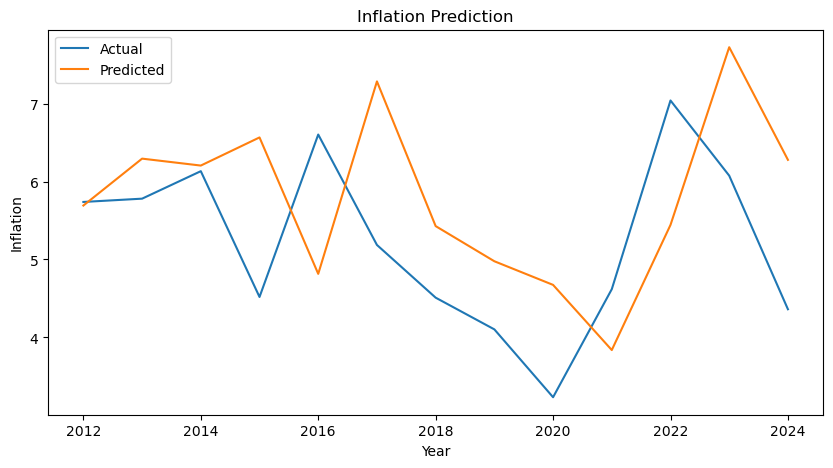

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(test["Year"], y_test, label="Actual")
plt.plot(test["Year"], y_pred, label="Predicted")

plt.xlabel("Year")
plt.ylabel("Inflation")
plt.title("Inflation Prediction")

plt.legend()
plt.show()

In [14]:
print("MSE:", mse)
print("R²:", r2)
print(model.coef_)

MSE: 1.9458102836843045
R²: -0.7247683409956438
[ 1.04500485 -0.18051516]


The model above gives an MSE = 1.95 and R^2 = −0.72. This indicates that the model performs worse than a simple baseline that predicts the mean inflation, suggesting that the lagged features alone do not capture enough predictive structure in the data. However, from the plot of predicted versus actual values, a similar pattern in the directional changes of inflation can be observed, even though the magnitudes differ.

Examining the model coefficients provides further insight. The coefficient for the first lag is positive and close to 1, indicating strong persistence in inflation from one year to the next, while the second lag has a smaller negative effect, suggesting a slight corrective behaviour. This reflects short-term memory in the system, but it is not enough for accurate prediction.

The limited performance of the model can be attributed to the nature of inflation as a macroeconomic variable. Inflation is influenced by multiple external factors, including monetary policy, economic growth, and global shocks, and therefore cannot be fully explained by past values alone. Additionally, inflation data is often volatile and subject to structural changes over time, which simple linear models do not capture well.

Future improvements to the model could include incorporating additional explanatory variables such as interest rates and GDP growth, and exploring more flexible models such as tree-based methods. These approaches would allow the model to better capture both time dependencies and nonlinear relationships in the data.